# Stroke Risk Classification with Explainable Machine Learning

## Project Overview

This project investigates machine learning approaches for classifying
stroke risk using demographic, lifestyle, and health-related features.

The dataset presents a significant class-imbalance challenge, with stroke
cases representing only a small proportion of the observations. Therefore,
model performance is evaluated using metrics beyond accuracy, including
precision, recall, F1-score, ROC-AUC, and PR-AUC.

### Objectives

- Perform exploratory data analysis and identify data-quality issues
- Build a leakage-safe preprocessing pipeline
- Compare multiple machine learning classification models
- Evaluate model performance using stratified cross-validation
- Investigate the effect of classification thresholds
- Analyze model predictions using explainability techniques
- Identify common sources of false-positive and false-negative predictions

### Important Note

This project is an educational machine learning study and is **not a
clinical diagnostic system**. The results should not be used for medical
decision-making.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

# **1. Dataset Overview**

## 1.1 Loading the Dataset

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f"Dataset shape: {df.shape}")
display(df.sample(10))

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5050,15581,Male,5.0,0,0,No,children,Urban,101.87,19.3,Unknown,0
3207,22917,Female,62.0,0,0,Yes,Private,Urban,92.99,29.3,formerly smoked,0
5047,25102,Female,51.0,0,0,Yes,Govt_job,Urban,95.16,42.7,formerly smoked,0
1172,30411,Female,40.0,0,0,No,Private,Rural,117.45,30.7,smokes,0
4485,66945,Female,49.0,0,0,Yes,Private,Urban,85.33,25.5,never smoked,0
4886,60562,Female,21.0,0,0,No,Private,Rural,55.12,21.8,never smoked,0
811,18412,Male,41.0,0,0,Yes,Private,Rural,82.32,27.9,Unknown,0
4059,38014,Male,24.0,0,0,Yes,Private,Urban,83.10,21.9,smokes,0
2654,29173,Male,52.0,0,0,Yes,Govt_job,Urban,67.50,27.7,smokes,0
525,29933,Female,5.0,0,0,No,children,Rural,86.11,19.0,Unknown,0


## 1.2 Dataset Structure

In [3]:
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of features: {df.shape[1]:,}")

display(df.dtypes.to_frame("Data Type"))

Number of observations: 5,110
Number of features: 12


,Data Type
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


### Feature Description

| Feature | Description | Type |
|---|---|---|
| `id` | Unique identifier | Identifier |
| `gender` | Gender of the individual | Categorical |
| `age` | Age of the individual | Numerical |
| `hypertension` | Presence of hypertension | Binary |
| `heart_disease` | Presence of heart disease | Binary |
| `ever_married` | Whether the individual has ever been married | Binary categorical |
| `work_type` | Type of occupation | Categorical |
| `Residence_type` | Urban or rural residence | Categorical |
| `avg_glucose_level` | Average glucose level | Numerical |
| `bmi` | Body mass index | Numerical |
| `smoking_status` | Smoking category | Categorical |
| `stroke` | Target indicating stroke occurrence | Binary target |

## 1.3 Statistical Summary

In [4]:
#Only numerical data
df[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


## 1.4 Missing Value Analysis

The dataset contains missing values only in the `bmi` feature. Rather than
removing these observations, missing BMI values will be imputed using the
median during model preprocessing.

The imputation step will be included inside the preprocessing pipeline so
that information from the validation/test data does not influence the
training process.

In [5]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

display(missing_values.to_frame("Missing Values"))

,Missing Values
bmi,201


##1.5 Duplicate Value Analysis

In [6]:
summary = pd.DataFrame({
    "Metric": ["Duplicate IDs", "Fully Duplicate Rows"],
    "Count": [df['id'].duplicated().sum(), df.duplicated().sum()]
})

display(summary)

,Metric,Count
0,Duplicate IDs,0
1,Fully Duplicate Rows,0


## 1.6 Categorical Feature Analysis

Categorical variables were inspected to identify their unique categories
and detect potential data-quality issues.

In [7]:
categorical_columns = ['gender','ever_married','work_type','Residence_type','smoking_status']
print("Number of categorical columns:",len(categorical_columns))

for col in categorical_columns:
    print(col)
    print(df[col].unique())
    print()

Number of categorical columns: 5
gender
['Male' 'Female' 'Other']

ever_married
['Yes' 'No']

work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type
['Urban' 'Rural']

smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']



## 1.7 Target Distribution

The target variable is highly imbalanced. Because stroke cases represent
only a small fraction of the dataset, accuracy alone may provide a
misleading assessment of model performance.

Therefore, recall, precision, F1-score, ROC-AUC, and PR-AUC will be used
alongside accuracy.

In [8]:
target_counts = df["stroke"].value_counts()

display(
    target_counts.rename(index={
        0: "No Stroke",
        1: "Stroke"
    }).to_frame("Count")
)

,Count
stroke,
No Stroke,4861
Stroke,249


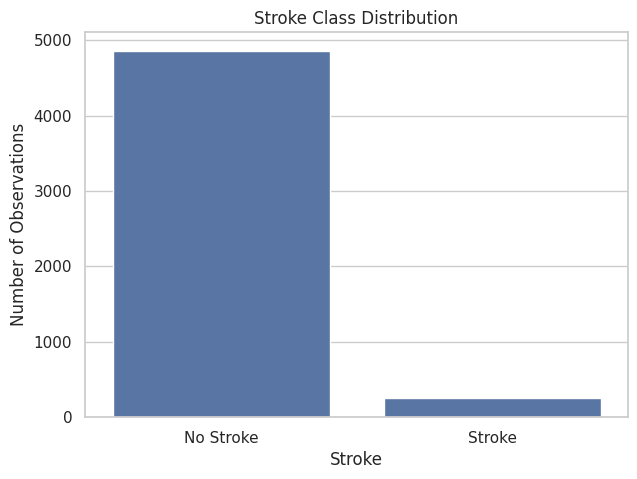

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="stroke"
)

plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Number of Observations")
plt.xticks([0, 1], ["No Stroke", "Stroke"])

plt.show()

In [10]:
class_percentage = (
    df["stroke"].value_counts(normalize=True).mul(100).rename(index={0: "No Stroke", 1: "Stroke"}))

display(
    class_percentage.to_frame("Percentage")
)

,Percentage
stroke,
No Stroke,95.127202
Stroke,4.872798


## 1.8 Data Quality Summary

In [11]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Duplicate rows",
        "Duplicate IDs",
        "Missing BMI values"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        df["id"].duplicated().sum(),
        df["bmi"].isnull().sum()
    ]
})

display(quality_summary)

,Metric,Value
0,Number of rows,5110
1,Number of columns,12
2,Duplicate rows,0
3,Duplicate IDs,0
4,Missing BMI values,201


##**2 Analysing the numerical variables**
Age-Values are fairly spread <br> <br>
Avg glucose level-We can see values are concentrated at around 60-120 & some values can be seen in the higher end can be potential outliers (Right skewed) <br> <br>
BMI-We can see values are concentrated at around 20-35 and some unusally high values can be potential outliers (Right skewed)

In [12]:
numerical_columns = ['age','avg_glucose_level','bmi']

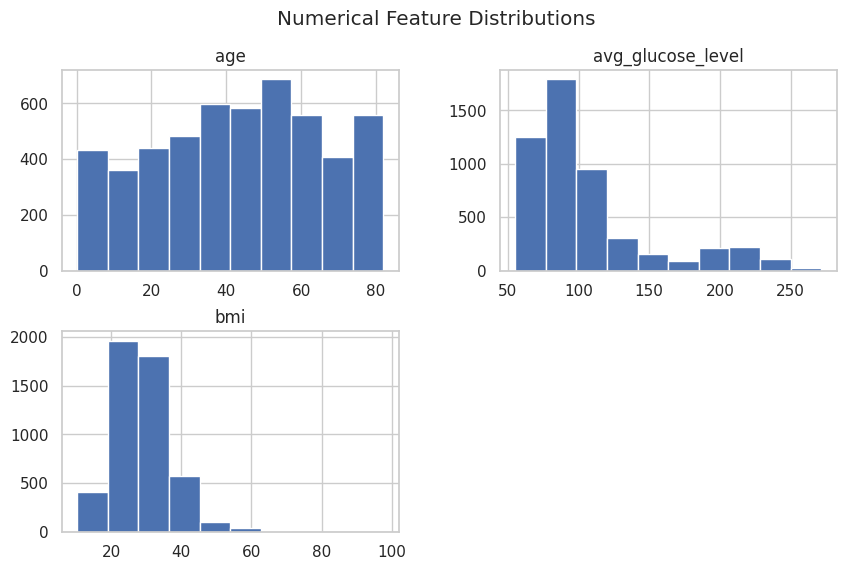

In [13]:
df[numerical_columns].hist(figsize=(10, 6))
plt.suptitle("Numerical Feature Distributions")
plt.show()

##2.1 Checking Skewness
📐 What is Skewness? Skewness measures the asymmetry of the distribution of a dataset.

Skewness = 0 → Perfectly symmetrical (e.g., normal distribution)

Skewness < 0 → Left-skewed (long tail on the left)

Skewness > 0 → Right-skewed (long tail on the right)

It helps you understand how balanced your data is and whether transformations are needed.

📊 Interpretation of Skewness Values:

Skewness Value Interpretation

~ 0 Symmetrical (normal-ish)

0 to ±0.5 Fairly symmetrical

±0.5 to ±1 Moderately skewed

greater than ±1 Highly skewed

In [14]:
df[numerical_columns].skew()

,0
age,-0.137059
avg_glucose_level,1.572284
bmi,1.055340


##2.2 Checking outliers
Because extreme observations may represent genuine patient characteristics,
they will not be removed from the dataset. Instead, their influence will be
evaluated using IQR-based capping within the preprocessing pipeline.

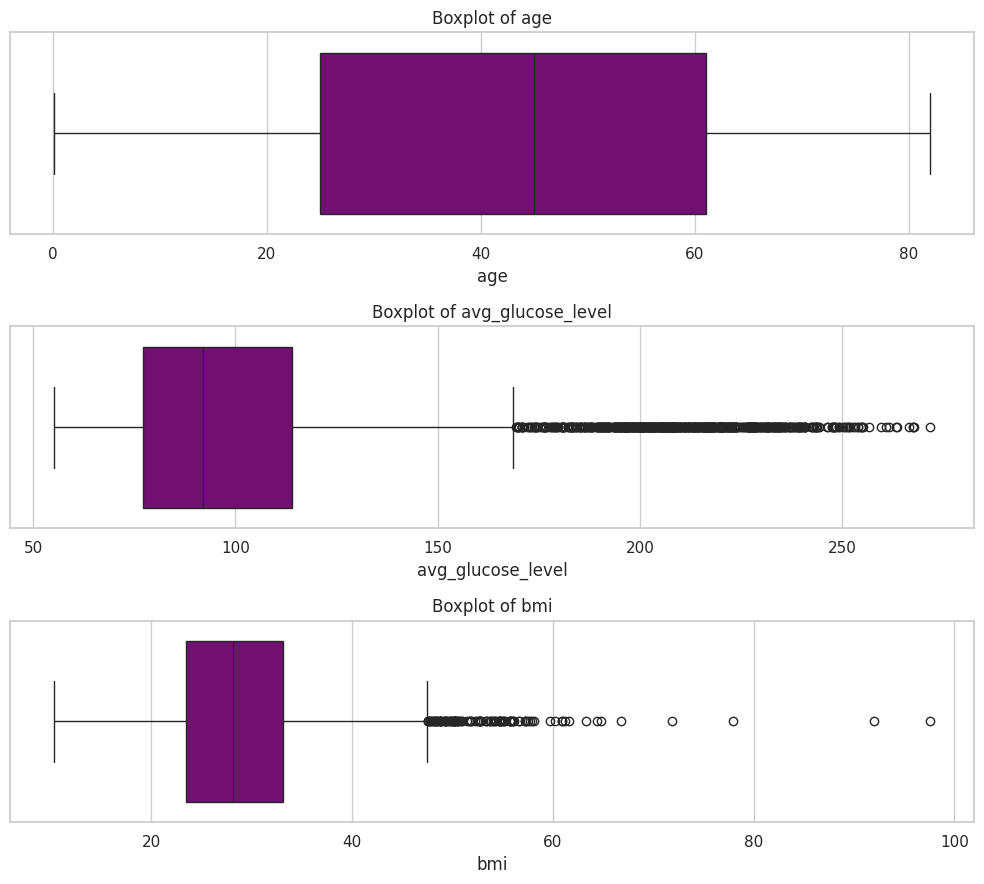

In [15]:
plt.figure(figsize=(10, 9))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    sns.boxplot(x=df[col], color='purple')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

##**3 Analysing categorical variables**

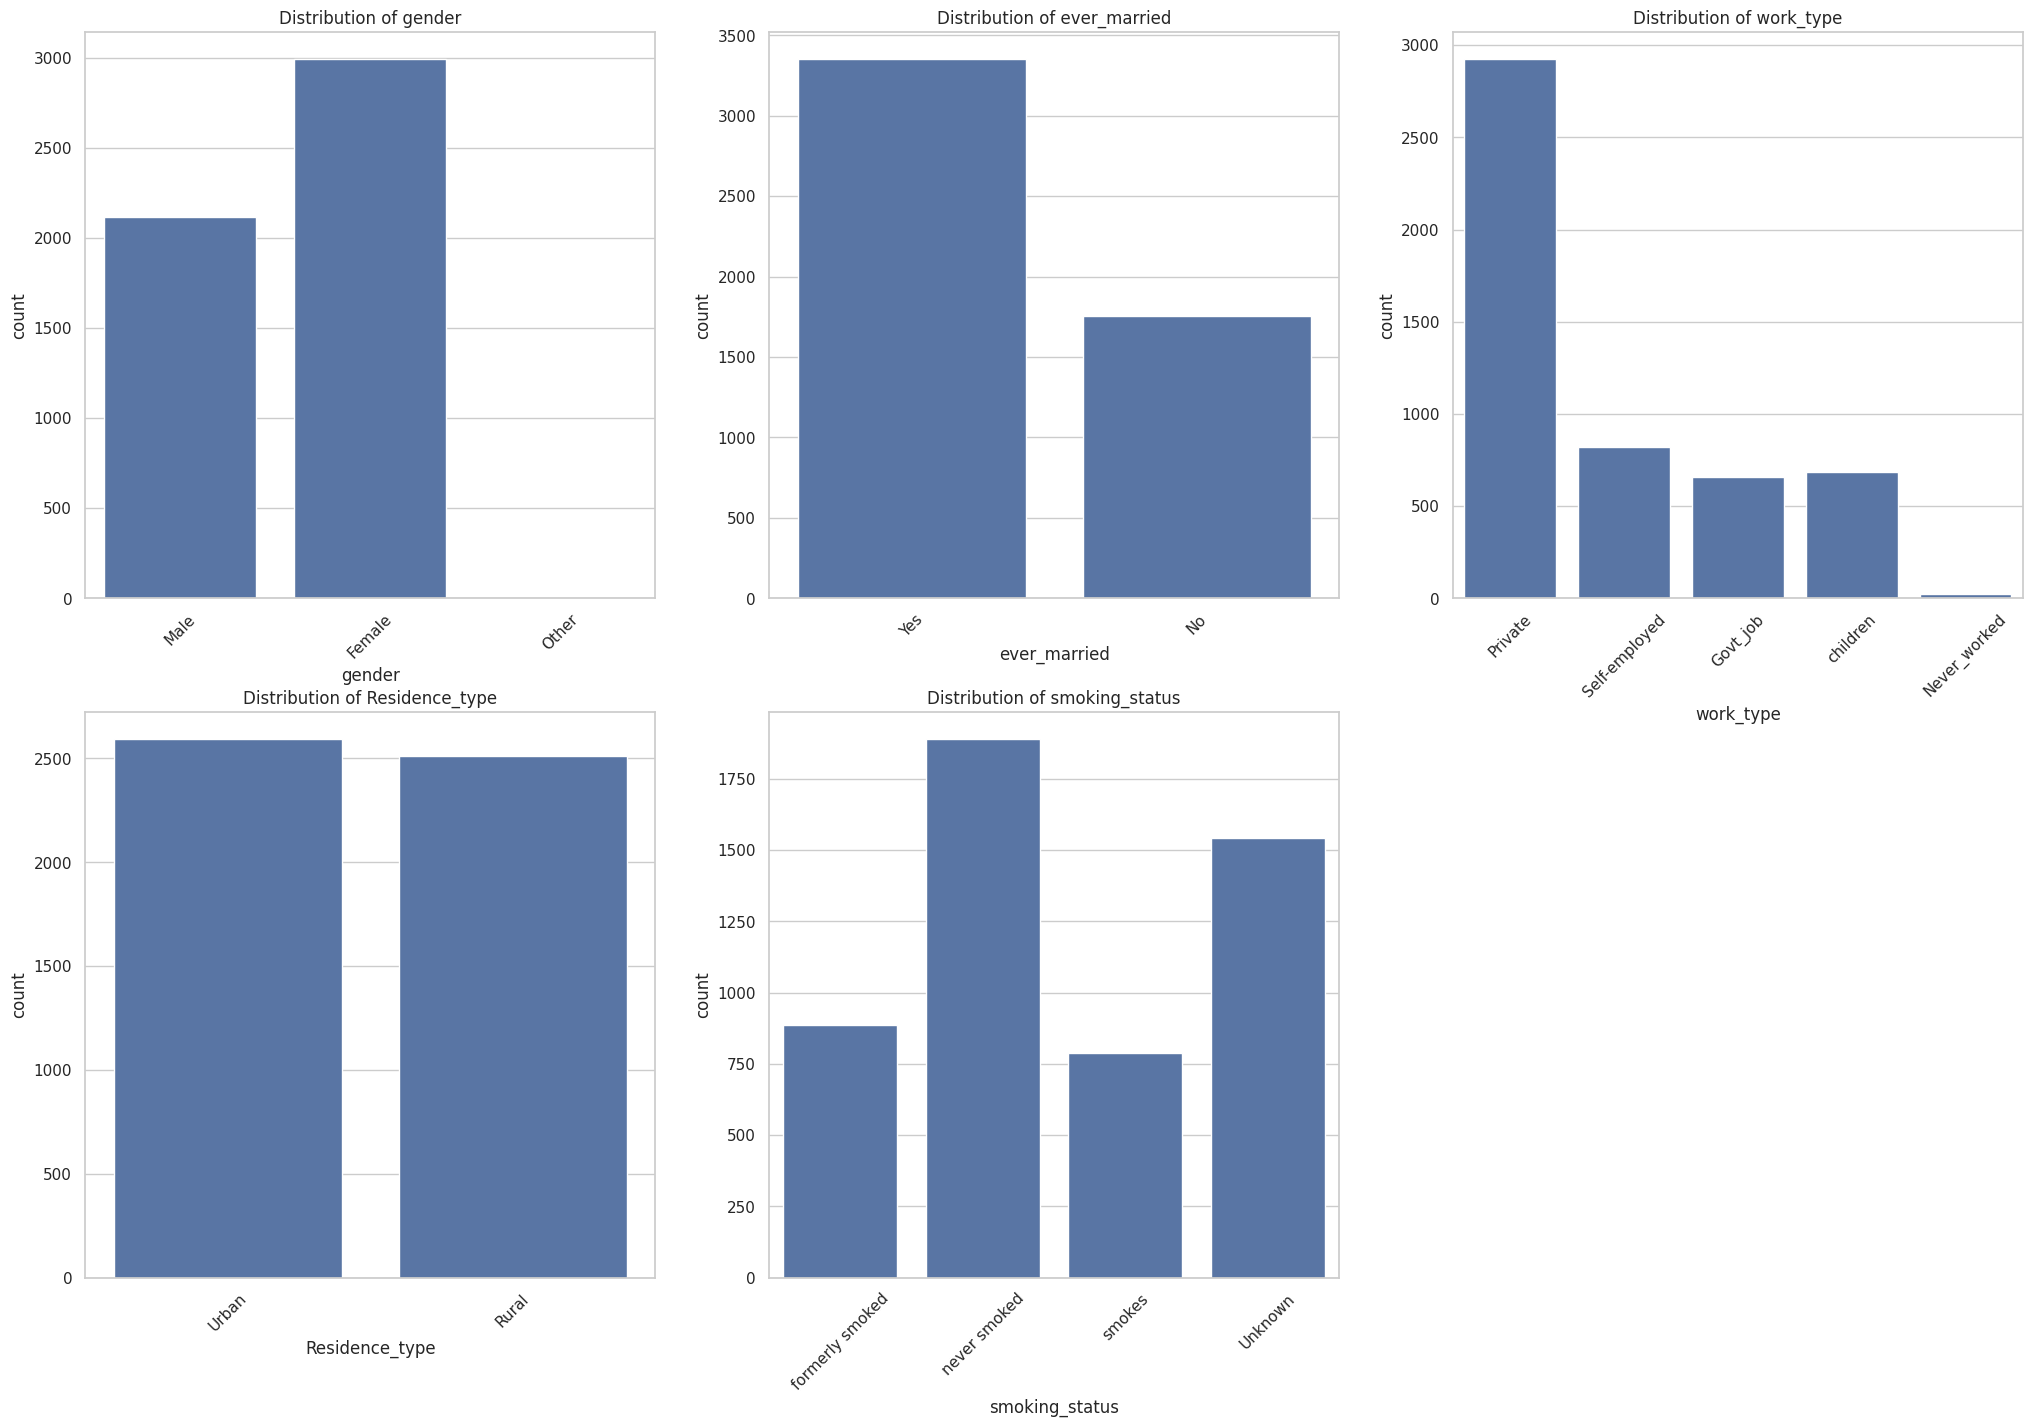

In [16]:
plt.figure(figsize=(25, 25))

for i in range(len(categorical_columns)):
    plt.subplot(3, 3, i + 1)

    sns.countplot(data=df, x=categorical_columns[i])

    plt.title(f"Distribution of {categorical_columns[i]}")
    plt.xticks(rotation=45)

##3.1 Corelation Analysis

##a. Pearson Correlation

No redundant columns found to drop

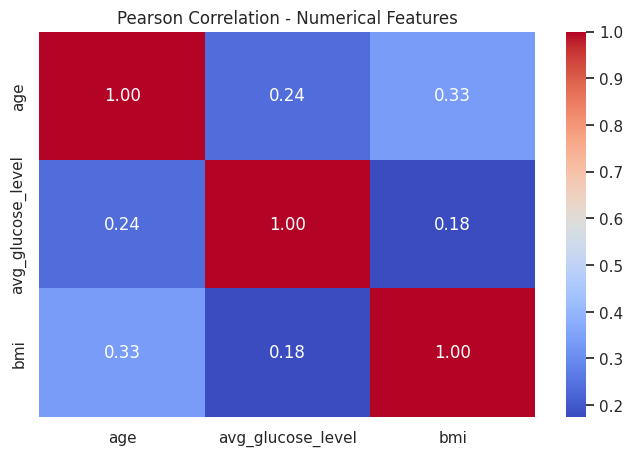

In [17]:
correlation_matrix = df[numerical_columns].corr(method='pearson')

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson Correlation - Numerical Features")
plt.show()

##b. Point-Biserial Correlation

p < 0.05 → statistically significant<br>
p >= 0.05 → not statistically significant



Age                → stronger association + significant<br>
Avg glucose        → weak association + significant<br>
BMI                → extremely weak association + significant<br>

Occurs betn numerical_feature vs categorical

In [18]:
from scipy.stats import pointbiserialr

for col in ['age', 'avg_glucose_level', 'bmi']:
    temp = df[[col, 'stroke']].dropna()

    correlation, p_value = pointbiserialr(temp[col], temp['stroke'])

    print(f"{col}:")
    print(f"Correlation = {correlation:.6f}")
    print(f"P-value = {p_value:.6e}")
    print()

age:
Correlation = 0.245257
P-value = 7.030778e-71

avg_glucose_level:
Correlation = 0.131945
P-value = 2.767811e-21

bmi:
Correlation = 0.042374
P-value = 2.983269e-03



##c. Cramer V

Higher Value means String association with stroke <br>
Value close to 0 means little or no association with stroke

In [19]:
from scipy.stats import chi2_contingency
import numpy as np

categorical_columns = [
    'gender',
    'hypertension',
    'heart_disease',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2_corrected /
        min(k_corrected - 1, r_corrected - 1)
    )

cramers_results = []

for col in categorical_columns:
    value = cramers_v(df[col], df['stroke'])
    cramers_results.append([col, value])

cramers_df = pd.DataFrame(
    cramers_results,
    columns=['Feature', "Cramer's V"]
)

print(cramers_df)

          Feature  Cramer's V
0          gender    0.000000
1    hypertension    0.125607
2   heart_disease    0.132178
3    ever_married    0.106478
4       work_type    0.094020
5  Residence_type    0.003993
6  smoking_status    0.071539


##3.2 Density Plot

Age<br>
* Your dataset contains people across a wide range of ages.
* There are fewer observations at very young and very old ages.
* Most observations are concentrated around middle/older adulthood.

Glucose<br>
* Most people have glucose levels around the lower range.
* There are some people with substantially higher glucose levels.
* The distribution is right-skewed.
* The second bump suggests the distribution may be multimodal.

BMI<br>
* Most observations have BMI around the 25–35 region.
* There are fewer observations with very high BMI.
* The distribution has a right tail. Therefore, BMI is right-skewed.

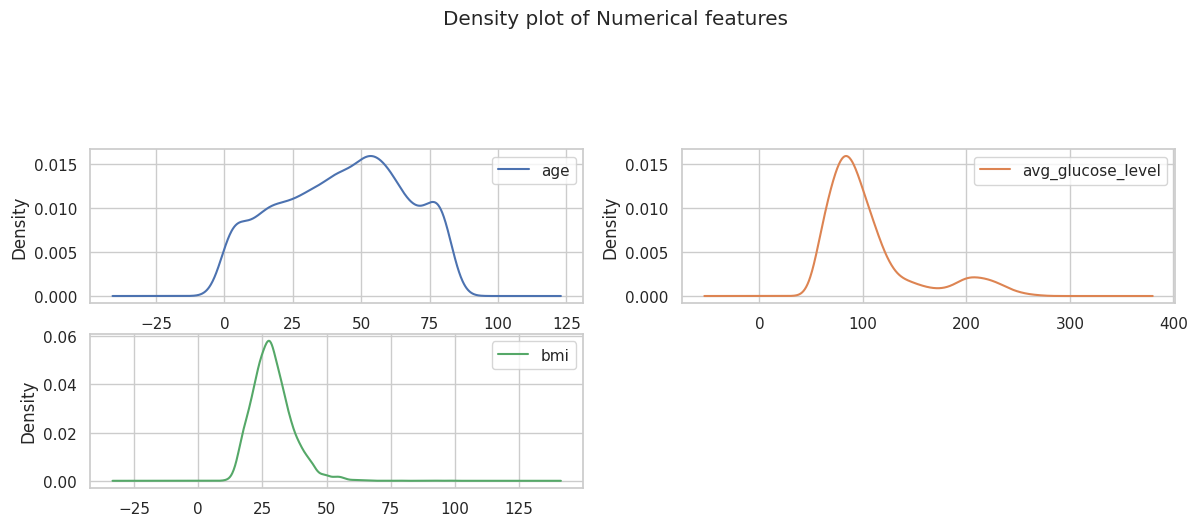

In [20]:
df[numerical_columns].plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

## **4 Data Pre-processing**

##4.1 Dropping unnecessary ID column

In [21]:
df=df.drop('id', axis=1)

## 4.2 Train-Test Split

The dataset was split into a training set (80%) and a testing set (20%). Stratified splitting was used because the target variable is highly imbalanced (only 4.87% stroke cases). Stratification keeps the same stroke ratio in both sets, otherwise the test set could end up with very few or no stroke cases.

In [22]:
X = df.drop('stroke', axis=1)
y = df['stroke']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


print("\nStroke count in training set:", y_train.sum())
print("Stroke count in test set:", y_test.sum())

Training set: (4088, 10)
Test set: (1022, 10)

Stroke count in training set: 199
Stroke count in test set: 50


## 4.3 Pre-processing Pipeline

Different preprocessing strategies are applied according to feature type.

- Numerical features are median-imputed, IQR-capped, and standardized.
- Binary numerical features are passed through unchanged.
- `ever_married` is ordinal-encoded because it contains two binary categories.
- Nominal categorical features are one-hot encoded because their categories
  do not have a meaningful numerical ordering.
- The identifier column `id` is excluded from model training.

All preprocessing operations are fitted only on the training data through the
scikit-learn pipeline to prevent data leakage.


In [23]:
numerical_features = ["age","avg_glucose_level","bmi"]
ordinal_features = ["ever_married","gender"]
binary_features = ["hypertension","heart_disease"]
nominal_features = ["work_type","Residence_type","smoking_status"]

In [24]:
class IQRCapper(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)

        iqr = q3 - q1

        self.lower = q1 - 1.5 * iqr
        self.upper = q3 + 1.5 * iqr

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        return np.clip(
            X,
            self.lower,
            self.upper
        )

    def get_feature_names_out(self, input_features=None):
        # Capping clips values in place; it never adds, drops, or
        # renames columns, so the output names are the input names.
        return np.asarray(input_features, dtype=object)

In [25]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("capper", IQRCapper()),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder())
])

nominal_pipeline = Pipeline([
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

##4.4 Column Transformer

In [26]:
preprocessor = ColumnTransformer([

    ("numeric", numeric_pipeline, numerical_features),

    ("binary", "passthrough", binary_features),

    ("ordinal", ordinal_pipeline, ordinal_features),

    ("nominal", nominal_pipeline, nominal_features)
])

## **5 Model Development**

In [27]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=RANDOM_STATE
    )
}

In [28]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [29]:
for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
KNN trained successfully.
Neural Network trained successfully.


# **6 Model Evaluation**

##6.1 K-Fold Cross Validation

Stratified 5-fold cross-validation is used to evaluate model performance
while preserving the class distribution within each fold.

The preprocessing pipeline is included within cross-validation so that
imputation, outlier capping, encoding, and scaling are fitted independently
within each training fold.

In [30]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [31]:
cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN
1,Decision Tree,NaN,NaN,NaN,NaN,NaN,NaN
2,KNN,NaN,NaN,NaN,NaN,NaN,NaN
3,Neural Network,NaN,NaN,NaN,NaN,NaN,NaN


## 6.2 Test set evaluation

In [32]:
test_results = []

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test, y_prob
        )
    })

test_results_df = pd.DataFrame(test_results)

display(
    test_results_df.round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.746,0.138,0.80,0.235,0.844,0.274
1,Decision Tree,0.828,0.179,0.70,0.285,0.821,0.177
2,KNN,0.949,0.333,0.04,0.071,0.603,0.078
3,Neural Network,0.927,0.162,0.12,0.138,0.734,0.128


##6.3 Model Performance Comparison

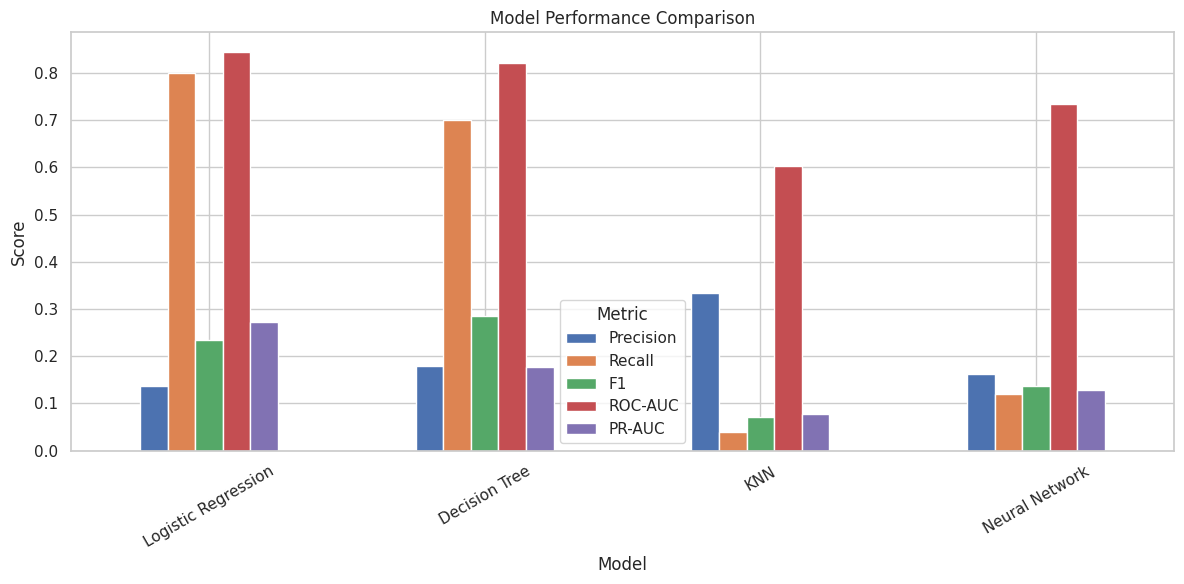

In [33]:
metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

plot_df = test_results_df.set_index("Model")[metrics]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 6.4 PR Curve

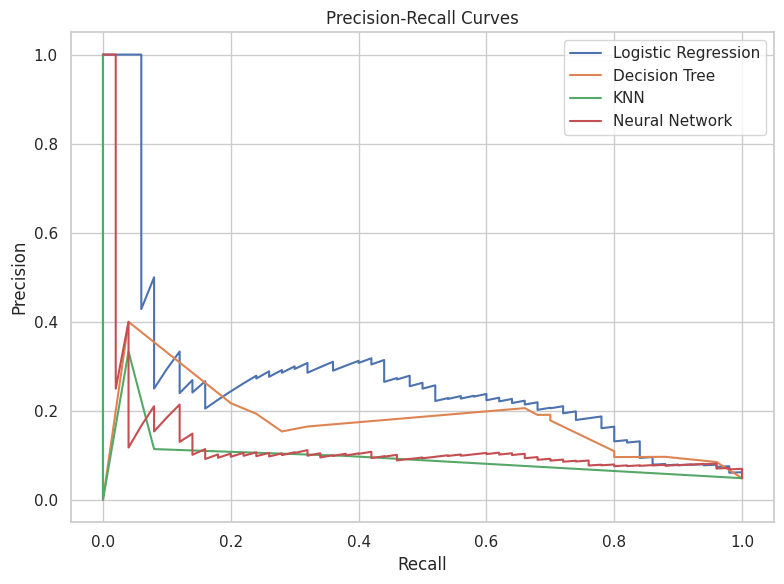

In [34]:
plt.figure(figsize=(8, 6))

for name, pipeline in pipelines.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

## 6.5 ROC-AUC Comparison

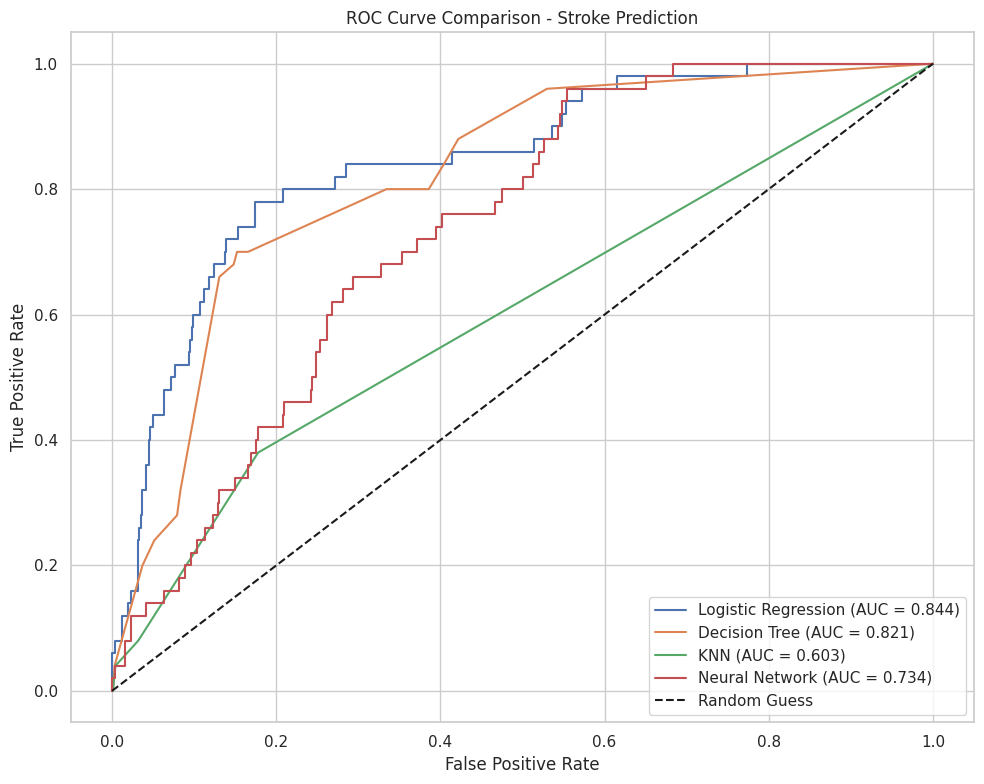

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Your trained pipelines
models = {
    "Logistic Regression": pipelines["Logistic Regression"],
    "Decision Tree": pipelines["Decision Tree"],
    "KNN": pipelines["KNN"],
    "Neural Network": pipelines["Neural Network"]
}

plt.figure(figsize=(10, 8))

for name, model in models.items():

    # Predict probabilities for the positive class (stroke = 1)
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random-guess baseline
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Guess"
)

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Stroke Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## 6.6 Confusion Matrix

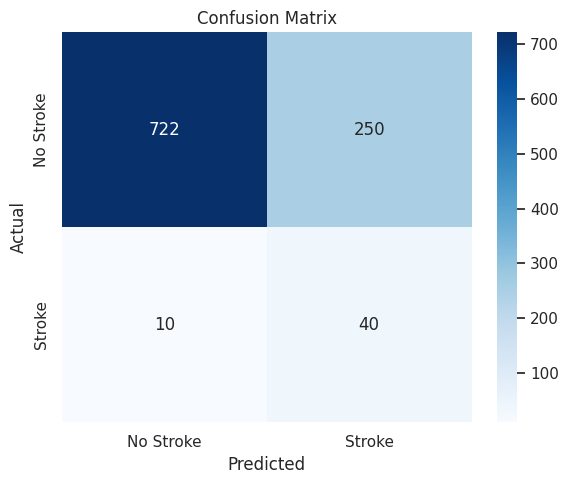

In [36]:
final_model = pipelines["Logistic Regression"]

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# **7 Error Analysis**

The model's incorrect predictions are examined to understand the types of
observations that are difficult to classify.

In [37]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_pred

error_analysis["Error Type"] = np.select(
    [
        (error_analysis["Actual"] == 1) &
        (error_analysis["Predicted"] == 0),

        (error_analysis["Actual"] == 0) &
        (error_analysis["Predicted"] == 1)
    ],
    [
        "False Negative",
        "False Positive"
    ],
    default="Correct"
)

display(
    error_analysis[
        error_analysis["Error Type"] != "Correct"
    ].head(20)
)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,Actual,Predicted,Error Type
1262,Male,67.0,0,0,Yes,Private,Rural,113.34,26.3,formerly smoked,0,1,False Positive
258,Female,74.0,1,0,Yes,Self-employed,Urban,205.84,54.6,never smoked,0,1,False Positive
4434,Female,63.0,1,0,Yes,Govt_job,Urban,192.50,29.0,never smoked,0,1,False Positive
2870,Male,75.0,0,0,Yes,Self-employed,Rural,82.35,25.3,never smoked,0,1,False Positive
2439,Female,56.0,0,0,Yes,Private,Rural,227.04,23.0,smokes,0,1,False Positive
3536,Male,65.0,1,0,Yes,Govt_job,Rural,189.88,34.0,never smoked,0,1,False Positive
2077,Male,74.0,0,0,Yes,Private,Rural,65.28,28.2,never smoked,0,1,False Positive
409,Female,80.0,0,0,Yes,Private,Rural,70.31,23.2,Unknown,0,1,False Positive
1418,Male,54.0,0,0,Yes,Private,Rural,150.27,38.2,smokes,0,1,False Positive
1854,Female,68.0,0,0,Yes,Self-employed,Rural,93.61,24.9,never smoked,0,1,False Positive


## **8 Explainability**

In [38]:
import shap

# Extract the fitted preprocessing step and the fitted Logistic Regression
# model from the pipeline chosen as the final model (Section 6.6).
fitted_preprocessor = final_model.named_steps["preprocessor"]
fitted_model = final_model.named_steps["model"]

# SHAP needs the numeric feature space the model actually sees, not the
# raw dataframe, so the fitted preprocessor is used to transform both sets.
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

feature_names = fitted_preprocessor.get_feature_names_out()

X_train_shap = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# A small background sample keeps the explainer fast while still
# representing the training distribution.
background = shap.sample(X_train_shap, 100, random_state=RANDOM_STATE)

explainer = shap.LinearExplainer(fitted_model, background)
shap_values = explainer(X_test_shap)

print("SHAP values computed for", X_test_shap.shape[0], "test observations")
print("Feature space:", X_test_shap.shape[1], "features")


SHAP values computed for 1022 test observations
Feature space: 18 features


## 8.1 Global Feature Importance (Summary Plot)

The beeswarm plot shows, for every test observation, how much each feature
pushed the predicted stroke risk up (red, high feature value) or down
(blue, low feature value). Features are ranked by their overall impact on
the model output.


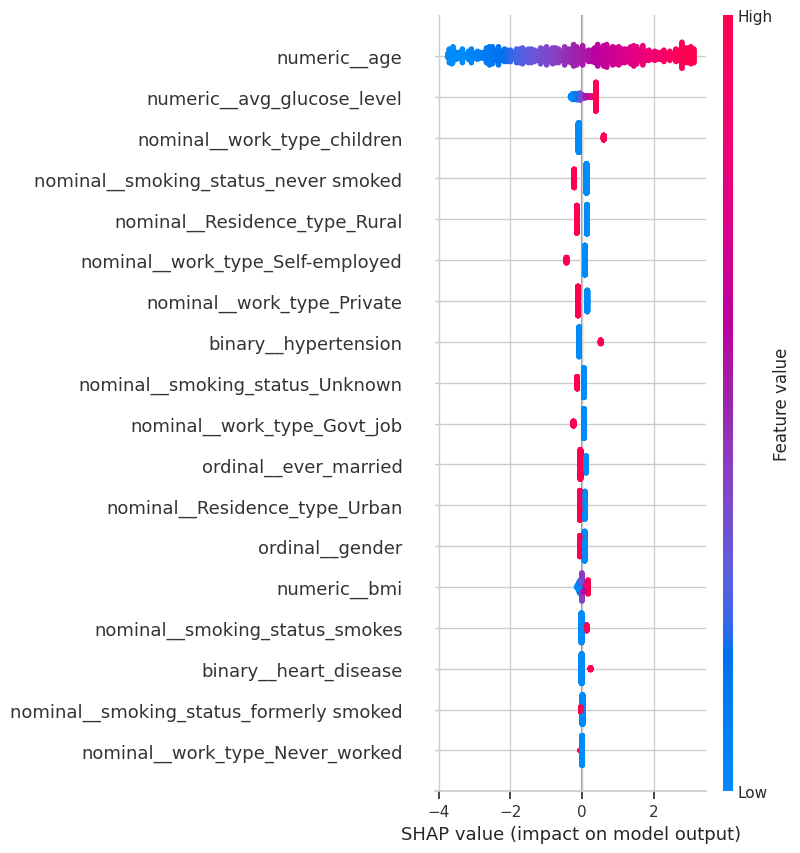

In [39]:
shap.summary_plot(shap_values, X_test_shap)


## 8.2 Mean |SHAP| Feature Importance

A simpler ranking of features by the average magnitude of their
contribution, independent of direction.


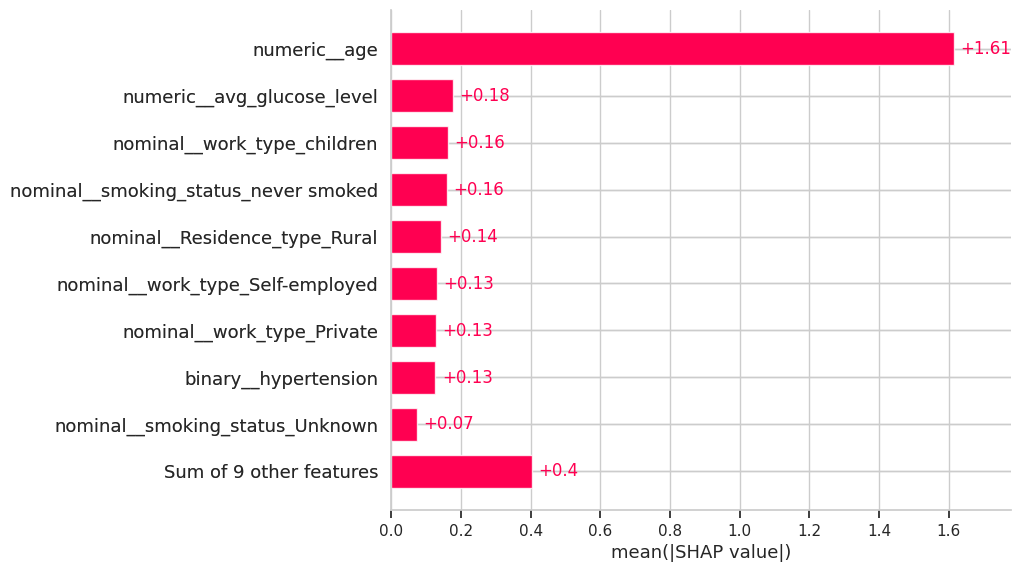

In [40]:
shap.plots.bar(shap_values)


## 8.3 Local Explanation for an Individual Prediction

Global importance shows what matters on average, but each patient is
different. The waterfall plot below explains a single prediction: it
starts at the model's average output (the base value) and shows how each
feature pushes that specific patient's predicted risk up or down. The
example chosen is a false negative from Section 7 - a stroke case the
model missed - to see which features masked the risk.


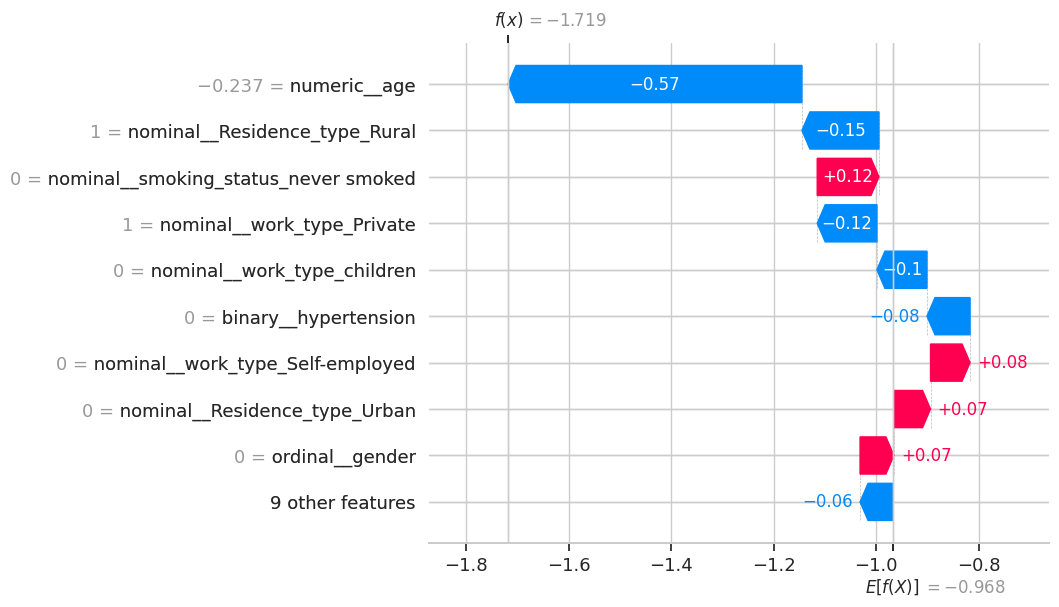

In [41]:
# Locate a false negative from the error analysis in Section 7 and explain it
fn_mask = (error_analysis["Error Type"] == "False Negative")
fn_position = np.where(fn_mask.values)[0][0]

shap.plots.waterfall(shap_values[fn_position])


## 8.4 SHAP Dependence Plots

Dependence plots show how a single feature's value relates to its SHAP
contribution across the whole test set, and whether that relationship is
influenced by another feature (shown via color).


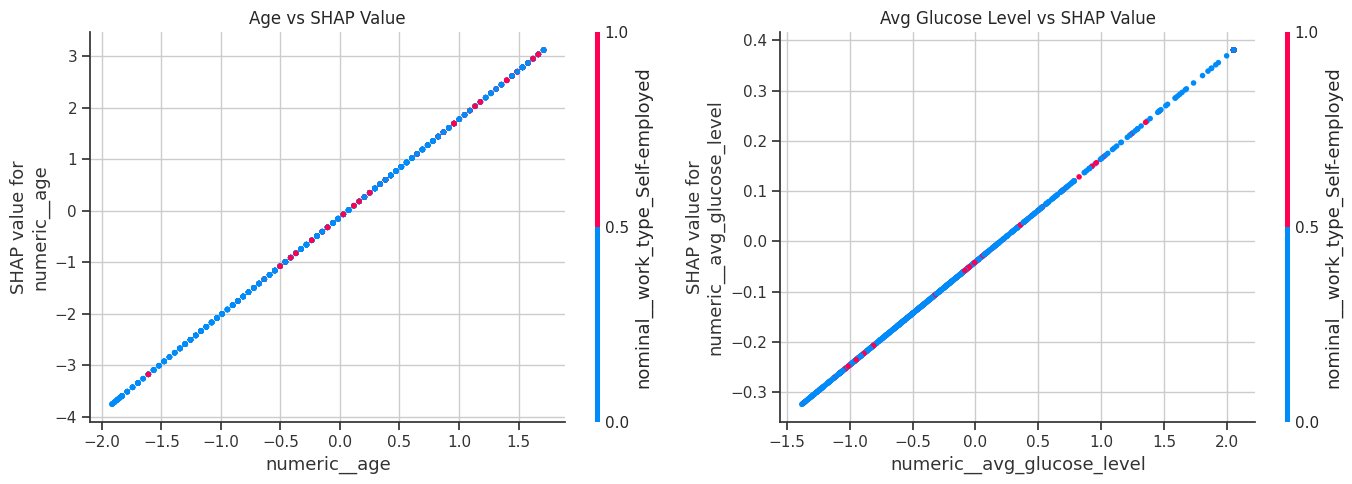

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    "numeric__age", shap_values.values, X_test_shap, ax=axes[0], show=False
)
axes[0].set_title("Age vs SHAP Value")

shap.dependence_plot(
    "numeric__avg_glucose_level", shap_values.values, X_test_shap, ax=axes[1], show=False
)
axes[1].set_title("Avg Glucose Level vs SHAP Value")

plt.tight_layout()
plt.show()


# **9 Conclusions**

This project investigated machine learning approaches for stroke-risk
classification using an imbalanced healthcare dataset.

The analysis demonstrated that accuracy alone is insufficient for evaluating
the models because the positive class represents a relatively small portion
of the dataset.

Multiple classification algorithms were compared using stratified
cross-validation and an independent test set. Performance was evaluated
using precision, recall, F1-score, ROC-AUC, and PR-AUC.

## Limitations

- The dataset is relatively small and highly imbalanced.
- The dataset may not represent the broader population.
- Model performance has not been externally validated.
- The results should not be interpreted as clinical evidence.
- The application is intended for educational and research purposes only.

In [43]:
import joblib
import os

final_pipeline = pipelines["Logistic Regression"]
os.makedirs("models", exist_ok=True)

joblib.dump(
    final_pipeline,
    "models/stroke_pipeline.pkl"
)

['models/stroke_pipeline.pkl']